# 03 — Insights: where the energy goes and how to get 2% below the baseline

**Data used:** analytical record (15-min) + DCS crown thermocouple TC MC3 (1-min), cleaned by `src/data_prep.py`. Only usable days (NCV meter working, ≥ 90% data, draw present) are included.

**Client values used, and why** (nothing else is taken from the client workbook):
| Client value | Used for |
|---|---|
| Baseline SFC 1,576.3 kcal/kg and target 1,544.8 | The number we must prove we beat. Our own baseline is recomputed and compared to it |
| Draw-band definition (5-t bands) | We recompute the band averages and 2% targets ourselves, so both sides use the same yardstick |

**Questions answered here**
1. Do we reproduce the client's baseline from raw data?
2. What drives SFC (draw, ageing, cullet, boost, NCV, air)?
3. Which levers exist, how big is each, and how sure are we?
4. Is 2% reachable, and against which target (per draw band or draw-adjusted)?

In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
d = pd.read_parquet('../data/processed/daily_clean.parquet')
h = pd.read_parquet('../data/processed/hourly_clean.parquet')
q = pd.read_parquet('../data/processed/ar_15min_clean.parquet')
u = d[d.usable].copy()
u['age_m'] = (u.index - pd.Timestamp('2025-09-01')).days / 30.44           # furnace-age proxy, months
u['E_g'] = u.energy_kcal / 1e6; u['gas_g'] = u.gas_kcal / 1e6
u['bb_g'] = u.bb_kwh * 860 / 1e6; u['mb_g'] = u.mb_kwh * 860 / 1e6
u['mon'] = u.index.to_period('M').astype(str)
base = u[u.in_baseline]
print('usable days:', len(u), '| in baseline period:', len(base), base.index.min().date(), '->', base.index.max().date())

usable days: 316 | in baseline period: 286 2025-10-11 -> 2026-07-31


## 1. Our baseline vs the client's
The client's period starts on 1 Sep 2025, but the NCV meter read 0 until 6 Oct 2025, so our baseline starts on the first usable day.

In [2]:
ours_mean = base.sfc.mean(); ours_w = base.energy_kcal.sum() / base.draw_kg.sum()
pd.DataFrame({'value (kcal/kg)': [ours_mean, ours_w, dp.CLIENT_BASELINE_SFC, ours_mean*0.98, dp.CLIENT_TARGET_SFC]},
             index=['Ours: mean of daily SFC', 'Ours: total energy / total draw', 'Client baseline (stated)',
                    'Ours x 0.98 (2% target)', 'Client target (stated)']).round(1)

,value (kcal/kg)
Ours: mean of daily SFC,1576.4
Ours: total energy / total draw,1573.1
Client baseline (stated),1576.3
Ours x 0.98 (2% target),1544.9
Client target (stated),1544.8


Our recomputed baseline (**≈1,576 kcal/kg**) matches the client's 1,576.3 almost exactly, using none of their numbers. So the raw data and the client's claim agree, and **1,544.8 is the target to beat**.

### 1b. Per draw band (client's band definition, our numbers)

In [3]:
bins = [45, 50, 55, 60, 65]
base['band'] = pd.cut(base.draw_t, bins, labels=['45-50', '50-55', '55-60', '60-65'], include_lowest=True)
bands = base.groupby('band', observed=True).agg(days=('sfc', 'size'), avg_draw_t=('draw_t', 'mean'), avg_sfc=('sfc', 'mean'))
bands['target_2pct'] = bands.avg_sfc * 0.98
bands['client_avg_sfc'] = [1765.4, 1662.6, 1565.1, 1520.1]     # client SFC Executive sheet, for comparison
bands.round(1)

,days,avg_draw_t,avg_sfc,target_2pct,client_avg_sfc
band,,,,,
45-50,6,48.6,1766.1,1730.7,1765.4
50-55,52,52.6,1664.0,1630.7,1662.6
55-60,152,57.9,1566.4,1535.1,1565.1
60-65,76,60.9,1521.3,1490.9,1520.1


## 2. What drives SFC: the draw-adjusted baseline model (M&V)
Two daily models of total energy (Gcal/day), fitted on the baseline period:
- **Model A (for claims):** energy = a + b·draw + c·cullet. This is the client-style "average furnace" yardstick.
- **Model B (for understanding):** Model A + furnace age (months).

Standard errors are HAC (robust to day-to-day autocorrelation).

In [4]:
mA = smf.ols('E_g ~ draw_t + cullet_pct', base).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
mB = smf.ols('E_g ~ draw_t + cullet_pct + age_m', base).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
tab = pd.DataFrame({'A coef': mA.params, 'A p': mA.pvalues, 'B coef': mB.params, 'B p': mB.pvalues}).round(3)
print('R² A = %.3f | R² B = %.3f | residual sd B = %.2f Gcal/day (%.1f%% of energy)' % (mA.rsquared, mB.rsquared, mB.resid.std(), 100*mB.resid.std()/base.E_g.mean()))
tab

R² A = 0.733 | R² B = 0.767 | residual sd B = 1.10 Gcal/day (1.2% of energy)


,A coef,A p,B coef,B p
Intercept,53.534,0.000,53.706,0.000
age_m,NaN,NaN,0.175,0.004
cullet_pct,0.128,0.245,-0.040,0.712
draw_t,0.604,0.000,0.634,0.000


In [5]:
fixed = mB.params.Intercept + mB.params.cullet_pct * base.cullet_pct.mean() + mB.params.age_m * base.age_m.mean()
var = mB.params.draw_t * base.draw_t.mean()
print('At average draw %.1f t: fixed energy %.1f Gcal/day (%.0f%%), draw-related %.1f Gcal/day' % (base.draw_t.mean(), fixed, 100*fixed/(fixed+var), var))
print('SFC change for +1 t/day draw: %.1f%%' % (100 * ((fixed + mB.params.draw_t*(base.draw_t.mean()+1))/(base.draw_t.mean()+1) / ((fixed+var)/base.draw_t.mean()) - 1)))
print('Ageing: +%.2f Gcal/day per month = +%.2f%% energy per month at the same draw' % (mB.params.age_m, 100*mB.params.age_m/base.E_g.mean()))

At average draw 57.5 t: fixed energy 54.1 Gcal/day (60%), draw-related 36.5 Gcal/day
SFC change for +1 t/day draw: -1.0%
Ageing: +0.17 Gcal/day per month = +0.19% energy per month at the same draw


**Reading the result:**
- **Draw is the biggest driver.** About 60% of the energy is fixed, so each +1 t/day of draw lowers SFC by about 1%.
- **Ageing is real and significant.** At the same draw and cullet, the furnace needs about **0.19% more energy every month** (p ≈ 0.004).
- **Cullet (16–20%) has no significant effect** in either model. It only changed about monthly, within a narrow range.

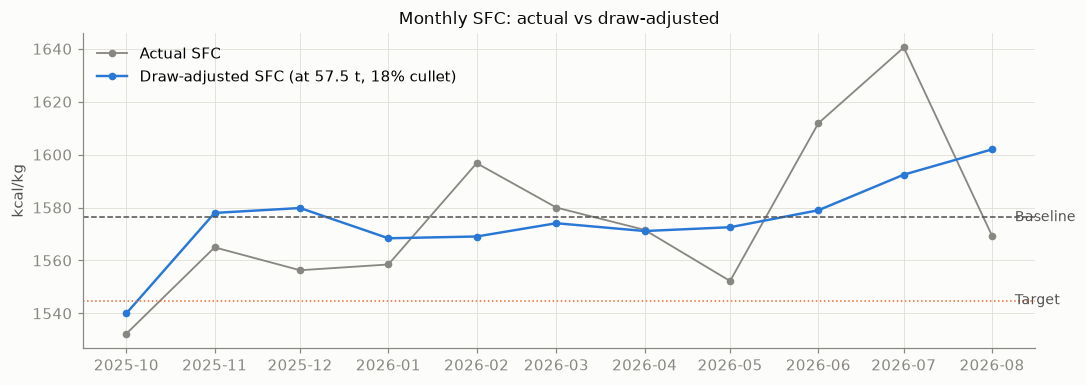

date,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08
draw_t,58.3,58.3,59.0,58.1,55.9,57.1,57.8,59.0,56.2,55.3,59.8
sfc,1532.3,1564.9,1556.3,1558.5,1596.8,1580.0,1571.5,1552.2,1611.9,1640.5,1569.3
sfc_draw_adj,1540.0,1578.0,1579.8,1568.4,1569.0,1574.1,1571.1,1572.6,1579.0,1592.4,1602.0


In [6]:
ref_draw = base.draw_t.mean(); ref_cul = base.cullet_pct.mean()
u['E_expected_A'] = mA.predict(u)
u['sfc_draw_adj'] = u.sfc * mA.predict(pd.DataFrame({'draw_t': [ref_draw]*len(u), 'cullet_pct': [ref_cul]*len(u)}, index=u.index)) / u.E_expected_A * u.draw_t / ref_draw
mon = u.groupby(u.index.to_period('M')).agg(draw_t=('draw_t','mean'), sfc=('sfc','mean'), sfc_draw_adj=('sfc_draw_adj','mean'))
fig, ax = plt.subplots(figsize=(10, 3.6))
x = mon.index.to_timestamp()
ax.plot(x, mon.sfc, color=MUTED, marker='o', ms=4, lw=1.2, label='Actual SFC')
ax.plot(x, mon.sfc_draw_adj, color=BLUE, marker='o', ms=4, label='Draw-adjusted SFC (at %.1f t, %.0f%% cullet)' % (ref_draw, ref_cul))
ax.axhline(dp.CLIENT_BASELINE_SFC, color=INK2, lw=1, ls='--'); ax.axhline(dp.CLIENT_TARGET_SFC, color=ORANGE, lw=1, ls=':')
ax.text(x[-1] + pd.Timedelta(days=8), dp.CLIENT_BASELINE_SFC, 'Baseline', color=INK2, fontsize=9, va='center')
ax.text(x[-1] + pd.Timedelta(days=8), dp.CLIENT_TARGET_SFC, 'Target', color=INK2, fontsize=9, va='center')
ax.set_ylabel('kcal/kg'); ax.set_title('Monthly SFC: actual vs draw-adjusted'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()
mon.round(1).T

In [7]:
recent = u[u.index >= '2026-06-01']
print('Draw-adjusted SFC, Jun-Aug 2026: %.0f kcal/kg = %+.1f%% vs baseline 1,576.3' % (recent.sfc_draw_adj.mean(), 100*(recent.sfc_draw_adj.mean()/dp.CLIENT_BASELINE_SFC - 1)))
print('=> to be 2%% below the baseline at average draw, the furnace now needs about %.1f%% less energy than in Jun-Aug 2026.' % (100*(1 - dp.CLIENT_TARGET_SFC/recent.sfc_draw_adj.mean())))

Draw-adjusted SFC, Jun-Aug 2026: 1591 kcal/kg = +0.9% vs baseline 1,576.3
=> to be 2% below the baseline at average draw, the furnace now needs about 2.9% less energy than in Jun-Aug 2026.


**Key insight: the starting point is worse than the baseline.** At the same draw, the furnace in Jun–Aug 2026 used more energy than the baseline average, which fits the ageing trend. So "2% below the baseline" means more than 2% below today's operation. This must be agreed with the client, by choosing one of:
- **per-draw-band targets** (simple, but they ignore ageing), or
- **draw-adjusted M&V** using Model A. Model A is fixed on the baseline period and has no ageing term, so it is conservative: it does not give credit for fighting ageing.

## 3. Lever analysis
### 3a. NCV compensation (Lever 1)
How much of an NCV change do operators correct, and how fast? Hourly data, response of NG to a +100 kcal/SCM NCV step.

In [8]:
hh = h[h.ncv.notna()].copy()
hh['dn'] = hh.ncv.diff()
ideal = hh.ng_scm.mean() / hh.ncv.mean() * 100           # NG change that keeps heat constant
resp = []
for k in range(0, 5):
    hh['dg'] = hh.ng_scm.shift(-k) - hh.ng_scm.shift(1)
    m = smf.ols('dg ~ dn', hh).fit()
    resp.append(dict(hours_after=k, ng_change_per_100_ncv=-m.params.dn*100, share_of_ideal=-m.params.dn*100/ideal))
resp = pd.DataFrame(resp); print('ideal NG change per +100 kcal/SCM (per hour, workbook units): %.2f' % ideal); resp.round(2)

ideal NG change per +100 kcal/SCM (per hour, workbook units): 3.47


,hours_after,ng_change_per_100_ncv,share_of_ideal
0,0,0.58,0.17
1,1,2.43,0.70
2,2,2.84,0.82
3,3,2.61,0.75
4,4,2.42,0.70


In [9]:
# Does a less steady gas heat input cost energy? (daily residual of Model B vs within-day heat variability)
heat_cv = (h.gas_kcal.groupby(h.index.normalize()).std() / h.gas_kcal.groupby(h.index.normalize()).mean()).rename('heat_cv')
ncv_sd = h.ncv.groupby(h.index.normalize()).std().rename('ncv_sd')
z = base.join(heat_cv).join(ncv_sd); z['resid'] = mB.resid
m = smf.ols('resid ~ heat_cv', z).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
m2 = smf.ols('resid ~ ncv_sd', z).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
print('Energy residual per +1 pt of within-day heat CV: %+.2f Gcal/day (p %.3f); mean heat CV %.1f%%' % (m.params.heat_cv/100, m.pvalues.heat_cv, 100*z.heat_cv.mean()))
print('Energy residual per +100 kcal/SCM of within-day NCV sd: %+.2f Gcal/day (p %.3f)' % (m2.params.ncv_sd*100, m2.pvalues.ncv_sd))
steady_saving = -m.params.heat_cv * (z.heat_cv.mean() - z.heat_cv.quantile(0.10)) / z.E_g.mean() * 100
print('If heat variability dropped to the steadiest 10%% of days: about %.2f%% energy saving (indicative)' % max(steady_saving, 0))

Energy residual per +1 pt of within-day heat CV: +0.10 Gcal/day (p 0.557); mean heat CV 2.1%
Energy residual per +100 kcal/SCM of within-day NCV sd: +0.13 Gcal/day (p 0.111)
If heat variability dropped to the steadiest 10% of days: about 0.00% energy saving (indicative)


**Reading the result:**
- Operators make about half of the needed NG correction in the next hour and most of it after 2–3 hours.
- Within-day heat variability shows **no significant** energy penalty (p ≈ 0.56), and NCV variability only a weak one (p ≈ 0.11). So no separate saving is claimed for "steadier heat".
- The value of exact NCV compensation (`NG = heat / NCV` every 15 min) is that it **delivers the chosen heat target exactly**, so the lower target from Lever 1 can actually be held. Its saving is counted inside Lever 1 (notebook 04).

### 3b. Best days vs worst days (draw- and age-adjusted)

In [10]:
z['grp'] = pd.qcut(z.resid, 4, labels=['best 25%', 'q2', 'q3', 'worst 25%'])
cols = ['resid', 'draw_t', 'cullet_pct', 'ncv', 'ncv_sd', 'heat_cv', 'air_per_mcal', 'bb_kwh', 'mb_kwh', 'mb3_temp', 'crown_tc', 'opt_temp', 'seed_count']
bw = z.groupby('grp', observed=True)[cols].mean()
bw.loc['best - worst'] = bw.loc['best 25%'] - bw.loc['worst 25%']
bw.T.round(3)

grp,best 25%,q2,q3,worst 25%,best - worst
resid,-1.372,-0.248,0.331,1.291,-2.662
draw_t,57.682,57.724,57.231,57.522,0.160
cullet_pct,17.597,17.380,17.648,17.542,0.056
ncv,9816.068,9822.786,9682.417,9496.848,319.220
ncv_sd,118.469,123.609,126.839,135.420,-16.951
heat_cv,0.022,0.021,0.021,0.022,0.000
air_per_mcal,1.258,1.267,1.268,1.272,-0.013
bb_kwh,8623.333,8750.822,8620.387,8802.303,-178.970
mb_kwh,7719.514,7594.415,7660.958,8222.293,-502.780
mb3_temp,1319.904,1320.396,1320.647,1320.400,-0.496


**Reading the result:** compared with the worst days, the best (most efficient) days have:
- **fewer seeds** (−2.3), so efficiency and quality go together and there is no trade-off within the historical range
- **less air per Mcal** (1.258 vs 1.272) and **less melter boost** (−500 kWh/day)
- slightly lower MB3 bottom temperature (−0.5 °C)
- higher and steadier NCV
- the **same optical temperature**, because operators hold it flat


### 3c. Electric boost: does it save energy? (correction of earlier finding F8)
F8 (from the baseline workbook) said 1 Gcal of boost displaces about 1.6 Gcal of gas. That regression had no ageing control, and barrier boost fell over the same months the furnace aged. Re-tested here with month fixed effects (compares days within the same month).

In [11]:
res = []
for name, f in [('no age control (as F8)', 'gas_g ~ draw_t + bb_g + mb_g'),
                ('linear age', 'gas_g ~ draw_t + bb_g + mb_g + age_m'),
                ('month fixed effects', 'gas_g ~ draw_t + bb_g + mb_g + C(mon)')]:
    m = smf.ols(f, u).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
    lo, hi = m.conf_int().loc['bb_g']
    res.append(dict(model=name, gas_Gcal_per_Gcal_barrier=m.params.bb_g, ci95=f'{lo:.2f} to {hi:.2f}', net_total_energy_per_Gcal_barrier=1 + m.params.bb_g))
pd.DataFrame(res).round(2)

,model,gas_Gcal_per_Gcal_barrier,ci95,net_total_energy_per_Gcal_barrier
0,no age control (as F8),-0.99,-1.25 to -0.73,0.01
1,linear age,-0.76,-0.92 to -0.61,0.24
2,month fixed effects,-0.81,-0.96 to -0.65,0.19


**Correction:** in this cleaned data, 1 Gcal of barrier boost replaces about **0.8 Gcal of gas** once ageing is controlled (about 1.0 without it), so total energy (and SFC) goes slightly **up** when boost goes up. **More boost is *not* a lever for SFC.**

The useful role of barrier boost is controlling the bottom temperature (next section). The energy lever is to use **no more boost than needed** to hold MB3 in band.

### 3d. What controls the bottom temperature (MB3)?

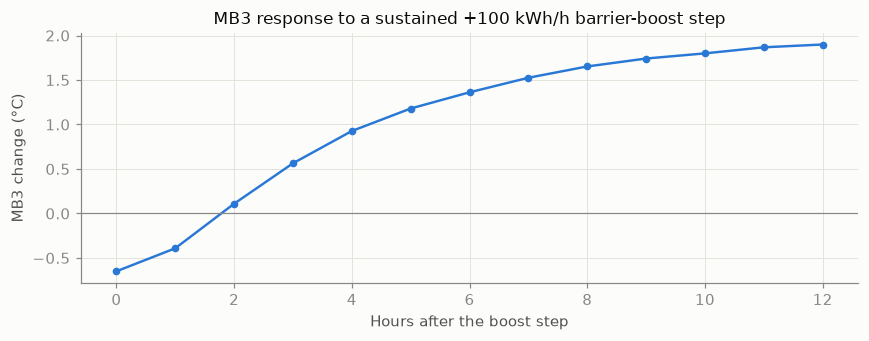

Steady-state gain: 1.90 °C per +100 kWh/h barrier boost (after 12 h)
Daily: MB3 per +1,000 kWh/day barrier 0.28 °C (p 0.039); per +1 Gcal/day gas 0.23 °C (p 0.064)


In [12]:
import recommender as rc
step = rc.mb3_impulse_response(h, lags=12)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(step.index, step.values * 100, color=BLUE, marker='o', ms=4)
ax.axhline(0, color=MUTED, lw=0.8); ax.set_xlabel('Hours after the boost step'); ax.set_ylabel('MB3 change (°C)')
ax.set_title('MB3 response to a sustained +100 kWh/h barrier-boost step'); plt.tight_layout(); plt.show()
print('Steady-state gain: %.2f °C per +100 kWh/h barrier boost (after 12 h)' % (step.iloc[-1]*100))
m = smf.ols('mb3_temp ~ bb_kwh + gas_g + draw_t + C(mon)', u).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
print('Daily: MB3 per +1,000 kWh/day barrier %.2f °C (p %.3f); per +1 Gcal/day gas %.2f °C (p %.3f)' % (m.params.bb_kwh*1000, m.pvalues.bb_kwh, m.params.gas_g, m.pvalues.gas_g))

Barrier boost is the handle for MB3: a sustained +100 kWh/h raises MB3 by about 2 °C within 6–12 h. Gas has a much smaller effect. This supports the plant's design for Model 2 (barrier boost from MB3).

*The dip in the first 1–2 hours is not physical.* Operators tend to raise boost when MB3 is already falling, so the regression picks up that feedback. Only the later, rising part of the curve is used as the furnace response.

### 3e. Quality guard-rail: seeds

In [13]:
m = smf.ols('seed_count ~ mb3_temp + crown_tc + E_g + draw_t + C(mon)', u.dropna(subset=['crown_tc'])).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
print({k: (round(v, 3), round(m.pvalues[k], 3)) for k, v in m.params.items() if not k.startswith('C(')})
print('Seed count: mean %.1f, P95 %.0f, max %d, spec 30 -> days above spec: %d of %d' % (u.seed_count.mean(), u.seed_count.quantile(.95), u.seed_count.max(), (u.seed_count > 30).sum(), len(u)))

{'Intercept': (-1602.848, np.float64(0.003)), 'mb3_temp': (0.149, np.float64(0.382)), 'crown_tc': (0.896, np.float64(0.006)), 'E_g': (0.283, np.float64(0.05)), 'draw_t': (-0.21, np.float64(0.059))}
Seed count: mean 14.7, P95 21, max 28, spec 30 -> days above spec: 0 of 316


Seeds are **not** higher on lower-energy days. If anything the reverse: more energy and a hotter crown go with *more* seeds, although that may partly be operators firing harder when seeds rise. On usable days seeds never exceeded the spec of 30 (P95 = 21). So quality headroom exists. Seeds remain a daily guard-rail during any trial.

### 3f. Air (Lever 2) and optical setpoint (Lever 3)

In [14]:
m = smf.ols('resid ~ air_per_mcal', z).fit(cov_type='HAC', cov_kwds={'maxlags': 7})
print('Energy residual per +0.01 SCM/Mcal air: %+.2f Gcal/day (p %.3f)' % (m.params.air_per_mcal/100, m.pvalues.air_per_mcal))
print('Air per Mcal: P10 %.3f, median %.3f, P90 %.3f' % tuple(u.air_per_mcal.quantile([.1, .5, .9])))
print('Optical daily mean (trustworthy days): sd %.2f °C, range %.1f-%.1f' % (u.loc[u.opt_day_ok, 'opt_temp'].std(), u.loc[u.opt_day_ok, 'opt_temp'].min(), u.loc[u.opt_day_ok, 'opt_temp'].max()))
air_target = u.air_per_mcal.quantile(0.25)
air_saving = m.params.air_per_mcal * (u.air_per_mcal.median() - air_target) / base.E_g.mean() * 100
print('Moving air from the median (%.3f) to the historical P25 (%.3f): about %.2f%% energy saving' % (u.air_per_mcal.median(), air_target, air_saving))

Energy residual per +0.01 SCM/Mcal air: +0.16 Gcal/day (p 0.003)
Air per Mcal: P10 1.246, median 1.267, P90 1.286
Optical daily mean (trustworthy days): sd 0.50 °C, range 1571.1-1576.2
Moving air from the median (1.267) to the historical P25 (1.258): about 0.16% energy saving


- **Air:** within the historical range (≈1.25–1.29 SCM/Mcal), days with less air per Mcal use significantly less energy (p ≈ 0.003). With no O₂ analyser, the recommender must not go below what the furnace has already run at, so the target is the **historical P25** (inside the proven range). The printed saving is the estimate.
- **Optical setpoint:** operators hold it within ±0.5 °C, so history can't show what a lower setpoint would do. It can only be found with a small step trial (−1 °C at a time, with daily seed checks).

## 4. Savings bridge: what can deliver 2%?

In [15]:
import recommender as rc
te = u[u.index >= '2026-06-01']
tgt = rc.walk_forward_gas_targets(u, te.index, tau=0.25, window=45)
frontier = (te.gas_g - tgt).sum() / te.E_g.sum() * 100
cover = (te.gas_g <= tgt).mean()
print('Walk-forward gas frontier (P25 of last 45 days), Jun-Aug 2026: saving %.2f%% of total energy, calibration %.0f%% (target 25%%)' % (frontier, 100*cover))

Walk-forward gas frontier (P25 of last 45 days), Jun-Aug 2026: saving 0.79% of total energy, calibration 24% (target 25%)


In [16]:
bridge = pd.DataFrame([
    ['1 Gas heat at the efficient frontier of recent operation (incl. NCV compensation)', round(frontier, 2), 'High (walk-forward back-test, calibrated)', '04'],
    ['2 Steadier heat input (no NCV lag), beyond 1', 0.0, 'Not significant, counted inside 1', '03'],
    ['3 Barrier boost only as needed for MB3 target', 'see nb05', 'Medium (MB3 response model)', '05'],
    ['4 Air per Mcal at historical P25 (inside proven range)', round(air_saving, 2), 'Medium (significant, observational; no O2)', '04'],
    ['5 Optical setpoint -1 to -2 °C (seed headroom)', 'trial', 'Needs step trial', 'trial'],
    ['Headwind: furnace ageing', round(-100*mB.params.age_m/base.E_g.mean(), 2), 'High (Model B), per month', '03'],
], columns=['lever', 'energy saving % (est.)', 'confidence', 'notebook'])
bridge

,lever,energy saving % (est.),confidence,notebook
0,1 Gas heat at the efficient frontier of recent...,0.79,"High (walk-forward back-test, calibrated)",04
1,"2 Steadier heat input (no NCV lag), beyond 1",0.0,"Not significant, counted inside 1",03
2,3 Barrier boost only as needed for MB3 target,see nb05,Medium (MB3 response model),05
3,4 Air per Mcal at historical P25 (inside prove...,0.16,"Medium (significant, observational; no O2)",04
4,5 Optical setpoint -1 to -2 °C (seed headroom),trial,Needs step trial,trial
5,Headwind: furnace ageing,-0.19,"High (Model B), per month",03


**Conclusions**
1. Our own baseline from raw data (≈1,576 kcal/kg) **confirms the client's 1,576.3**. The 2% target is 1,544.8 overall, or 2% below each draw band.
2. **Draw explains most SFC variation, and ageing adds about 0.19%/month.** Judge success per draw band or draw-adjusted (both prepared here); never compare raw monthly averages.
3. The **largest, best-evidenced lever is gas**: target the efficient frontier of the last 45 days and apply exact NCV compensation every 15 min. Sized in notebook 04.
4. **Barrier boost is a temperature handle, not an energy saver** (corrected F8). Use the minimum boost that holds MB3. Sized in notebook 05.
5. **Air** can be trimmed to the efficient end of its own history (about 0.15%; it may partly overlap with lever 1). Going below that needs an O₂ analyser. The **optical setpoint** needs a step trial.
6. Today the furnace runs about 0.9% above the baseline at the same draw, so 2% below the *baseline* means about 2.9% below *today*. Levers 1 + 4 give about 1%; notebook 05 adds the boost lever. The rest has to come from the optical-setpoint trial and/or higher draw. The per-draw-band view makes the gap visible band by band.